In [3]:
!pip install pandas-datareader

   ---------------------------------------- 0.0/109.5 kB ? eta -:--:--
   --- ------------------------------------ 10.2/109.5 kB ? eta -:--:--
   ------- ------------------------------- 20.5/109.5 kB 320.0 kB/s eta 0:00:01
   --------------------- ----------------- 61.4/109.5 kB 544.7 kB/s eta 0:00:01
   -------------------------------------- 109.5/109.5 kB 703.7 kB/s eta 0:00:00


In [62]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [64]:
assets = ['SPY', 'TLT', 'LQD', 'GLD']

raw = yf.download(assets, start='2012-01-01', end='2024-01-01', progress=False)

prices = raw['Close']
returns = np.log(prices).diff().dropna()

In [66]:
macro_assets = {
    "SPX": "^GSPC",
    "VIX": "^VIX",
    "TNX": "^TNX",
    "DXY": "DX-Y.NYB"
}

macro_raw = yf.download(list(macro_assets.values()),
                        start='2012-01-01',
                        end='2024-01-01',
                        progress=False)['Close']

macro_raw.columns = list(macro_assets.keys())

macro_returns = np.log(macro_raw).diff().dropna()

In [68]:
X = StandardScaler().fit_transform(macro_returns)

pca = PCA(n_components=3)
macro_factors = pca.fit_transform(X)

factor_df = pd.DataFrame(
    macro_factors,
    index=macro_returns.index,
    columns=['F1_Market', 'F2_Rates', 'F3_Risk']
)

print(pca.explained_variance_ratio_)

[0.47536259 0.28256579 0.17861937]


In [70]:
data = returns.join(factor_df, how='inner')
data = data.dropna()

In [72]:
X = data[['F1_Market', 'F2_Rates', 'F3_Risk']].values
X = StandardScaler().fit_transform(X)

results = {}

for asset in ['SPY', 'TLT', 'LQD', 'GLD']:
    y = data[asset].values

    model = LinearRegression()
    model.fit(X, y)

    results[asset] = {
        "alpha": model.intercept_,
        "betas": model.coef_,
        "r2": model.score(X, y)
    }

results

{'SPY': {'alpha': 0.0005133660543302993,
  'betas': array([-0.0096548 , -0.00158386, -0.00113317]),
  'r2': 0.8682962005252566},
 'TLT': {'alpha': 4.296077872758684e-05,
  'betas': array([ 0.00425024, -0.0042823 , -0.00477873]),
  'r2': 0.6800324500241385},
 'LQD': {'alpha': 0.00012923301242467652,
  'betas': array([-7.39864458e-05, -2.54442684e-03, -1.96775901e-03]),
  'r2': 0.4090149228056137},
 'GLD': {'alpha': 7.876410348099299e-05,
  'betas': array([ 0.00040337, -0.00463606,  0.00024934]),
  'r2': 0.2442855795241421}}

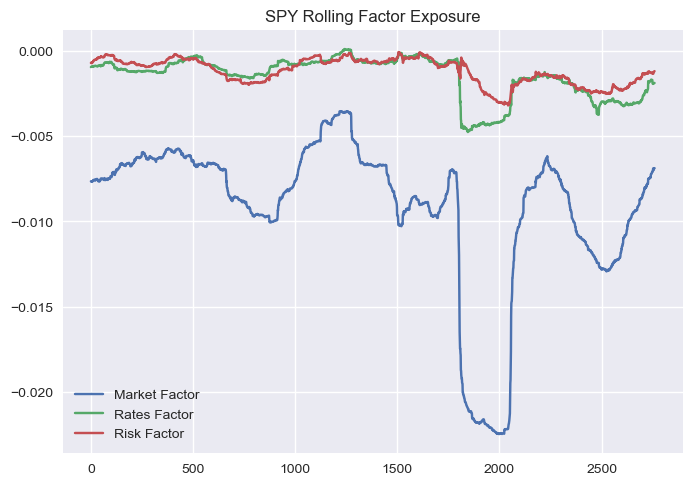

In [74]:
window = 252  # 1 year rolling

rolling_betas = []

asset = 'SPY'

for i in range(window, len(data)):
    y = data[asset].iloc[i-window:i]
    Xw = data[['F1_Market','F2_Rates','F3_Risk']].iloc[i-window:i]

    Xw = StandardScaler().fit_transform(Xw)

    model = LinearRegression().fit(Xw, y)

    rolling_betas.append(model.coef_)

rolling_betas = np.array(rolling_betas)

plt.figure()
plt.plot(rolling_betas[:,0], label="Market Factor")
plt.plot(rolling_betas[:,1], label="Rates Factor")
plt.plot(rolling_betas[:,2], label="Risk Factor")
plt.legend()
plt.title("SPY Rolling Factor Exposure")
plt.show()

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

In [78]:
def factor_risk_contribution(data, assets, factors):
    contributions = {}

    X = data[factors].values
    X = StandardScaler().fit_transform(X)

    for asset in assets:
        y = data[asset].values

        model = LinearRegression()
        model.fit(X, y)

        y_pred = model.predict(X)

        total_var = np.var(y)
        explained_var = np.var(y_pred)

        factor_shares = (model.coef_ ** 2)
        factor_shares = factor_shares / factor_shares.sum()

        contributions[asset] = {
            "R2": model.score(X, y),
            "Systematic_Risk_%": explained_var / total_var,
            "Factor_Breakdown_%": factor_shares
        }

    return contributions

In [80]:
assets_list = ['SPY', 'TLT', 'LQD', 'GLD']
factors = ['F1_Market', 'F2_Rates', 'F3_Risk']

risk_contrib = factor_risk_contribution(data, assets_list, factors)

risk_contrib

{'SPY': {'R2': 0.8682962005252566,
  'Systematic_Risk_%': 0.8682962005252571,
  'Factor_Breakdown_%': array([0.96090316, 0.02585996, 0.01323689])},
 'TLT': {'R2': 0.6800324500241385,
  'Systematic_Risk_%': 0.6800324500241389,
  'Factor_Breakdown_%': array([0.30494378, 0.30956189, 0.38549432])},
 'LQD': {'R2': 0.4090149228056137,
  'Systematic_Risk_%': 0.4090149228056138,
  'Factor_Breakdown_%': array([5.28803641e-04, 6.25417520e-01, 3.74053676e-01])},
 'GLD': {'R2': 0.2442855795241421,
  'Systematic_Risk_%': 0.24428557952414195,
  'Factor_Breakdown_%': array([0.0074918, 0.9896455, 0.0028627])}}

In [82]:
table = pd.DataFrame({
    asset: {
        "R2": risk_contrib[asset]["R2"],
        "Systematic_Risk": risk_contrib[asset]["Systematic_Risk_%"],
        "F1": risk_contrib[asset]["Factor_Breakdown_%"][0],
        "F2": risk_contrib[asset]["Factor_Breakdown_%"][1],
        "F3": risk_contrib[asset]["Factor_Breakdown_%"][2],
    }
    for asset in assets_list
}).T

table

,R2,Systematic_Risk,F1,F2,F3
SPY,0.868296,0.868296,0.960903,0.025860,0.013237
TLT,0.680032,0.680032,0.304944,0.309562,0.385494
LQD,0.409015,0.409015,0.000529,0.625418,0.374054
GLD,0.244286,0.244286,0.007492,0.989645,0.002863


In [84]:
def rolling_betas(data, asset, factors, window=252):
    X = data[factors]
    y = data[asset]

    X_scaled = StandardScaler().fit_transform(X)

    betas = []

    for i in range(window, len(data)):
        X_win = X_scaled[i-window:i]
        y_win = y.iloc[i-window:i]

        model = LinearRegression()
        model.fit(X_win, y_win)

        betas.append(model.coef_)

    betas = np.array(betas)

    return pd.DataFrame(
        betas,
        columns=factors,
        index=data.index[window:]
    )

In [86]:
spy_betas = rolling_betas(
    data,
    asset='SPY',
    factors=['F1_Market', 'F2_Rates', 'F3_Risk']
)

spy_betas.head()

,F1_Market,F2_Rates,F3_Risk
Date,,,
2013-01-07,-0.008723,-0.001226,-0.000767
2013-01-08,-0.008731,-0.001213,-0.000771
2013-01-09,-0.008722,-0.001223,-0.000755
2013-01-10,-0.008736,-0.001215,-0.000784
2013-01-11,-0.008739,-0.001214,-0.000785


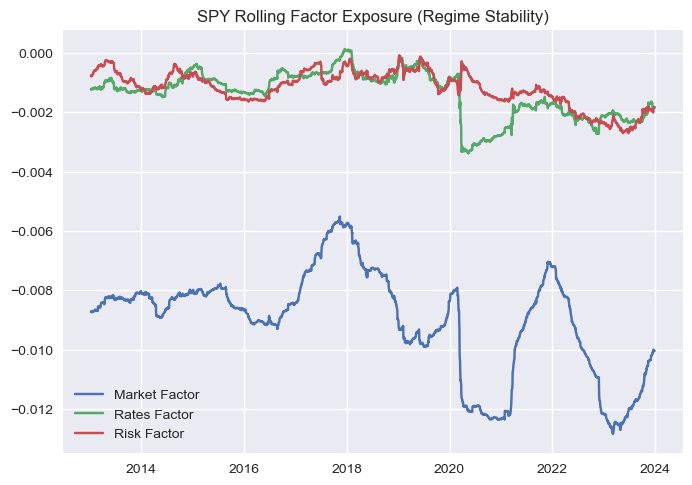

In [88]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(spy_betas['F1_Market'], label='Market Factor')
plt.plot(spy_betas['F2_Rates'], label='Rates Factor')
plt.plot(spy_betas['F3_Risk'], label='Risk Factor')

plt.title("SPY Rolling Factor Exposure (Regime Stability)")
plt.legend()
plt.show()

In [94]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

factor_data = data[['F1_Market', 'F2_Rates', 'F3_Risk']]

X = StandardScaler().fit_transform(factor_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
regimes = kmeans.fit_predict(X)

data['Regime'] = regimes

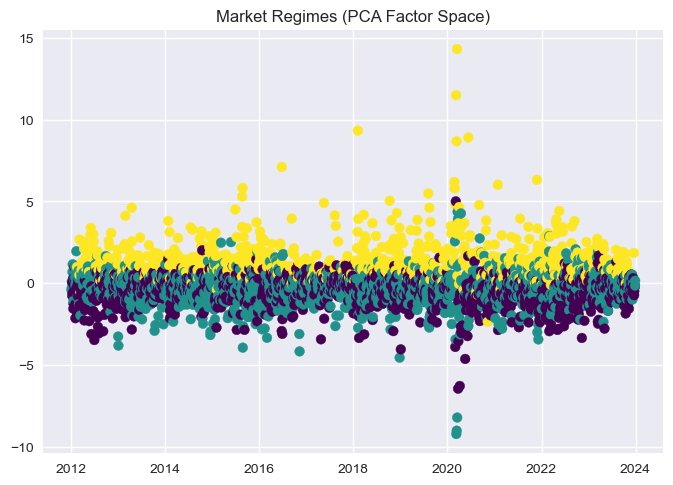

In [96]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(data.index, data['F1_Market'], c=data['Regime'], cmap='viridis')
plt.title("Market Regimes (PCA Factor Space)")
plt.show()

In [98]:
def factor_var(factor_series, alpha=0.05):
    return np.percentile(factor_series, 100 * alpha)

In [100]:
factor_vars = {}

for f in ['F1_Market', 'F2_Rates', 'F3_Risk']:
    factor_vars[f] = {
        "VaR_5%": factor_var(data[f]),
        "Volatility": data[f].std()
    }

factor_vars

{'F1_Market': {'VaR_5%': -1.9815943311704274,
  'Volatility': 1.3791598397096037},
 'F2_Rates': {'VaR_5%': -1.5928732916453794, 'Volatility': 1.0633148907986276},
 'F3_Risk': {'VaR_5%': -1.2118355656595374, 'Volatility': 0.8454080483428296}}

In [102]:
data['Crisis_Index'] = (
    np.abs(data['F1_Market']) +
    np.abs(data['F2_Rates']) +
    np.abs(data['F3_Risk'])
)

In [104]:
data['Crisis_Index_Smooth'] = data['Crisis_Index'].rolling(20).mean()

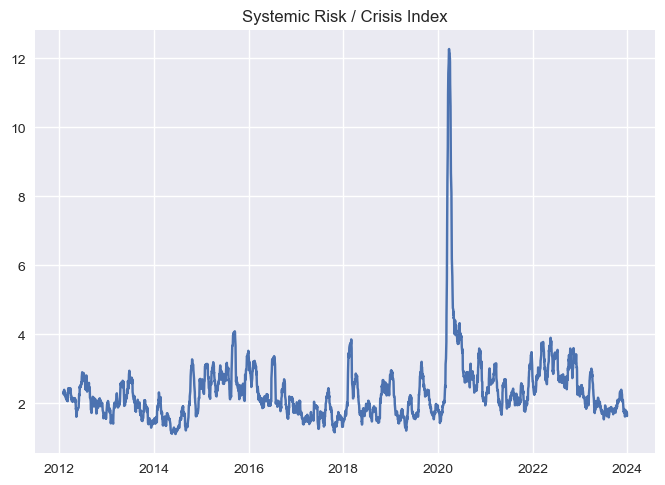

In [106]:
plt.figure()

plt.plot(data['Crisis_Index_Smooth'])
plt.title("Systemic Risk / Crisis Index")
plt.show()